Distances: [ 2  4  6  8 10 12]


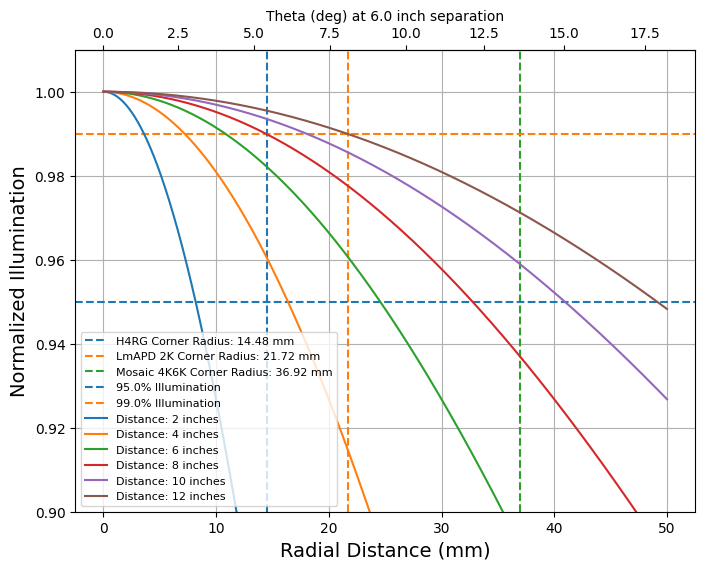

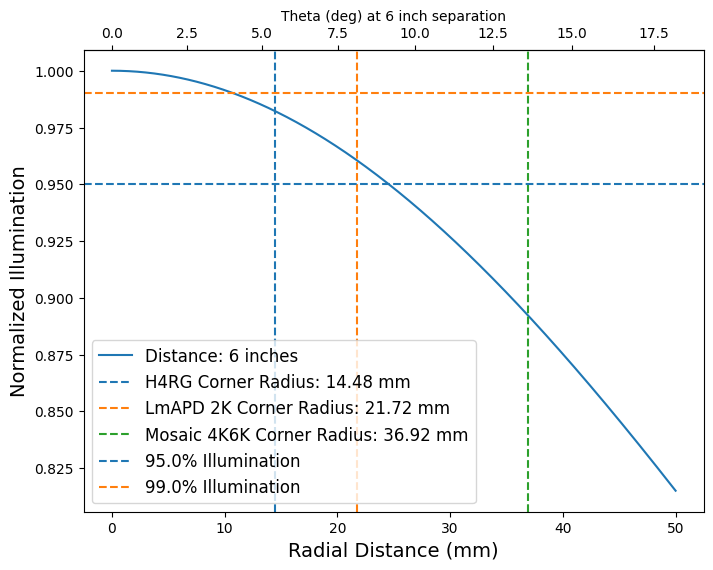

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

distances = np.arange(2, 13, 2) # distances in inches
print("Distances:", distances)

h4rg_r = np.sqrt((2048*0.010)**2 + (2048*0.010)**2)/2 # radius to corner in mm
lmapd_2k_r = np.sqrt((2048*0.015)**2 + (2048*0.015)**2)/2 # radius to corner in mm
mosaic_4k6k_r = np.sqrt((4*1024*0.01)**2 + (6*1024*0.01)**2)/2 # radius to corner in mm

r = np.linspace(0, 50, 1000) # radius values from 0 to corner
fig, ax = plt.subplots(figsize=(8,6))
color_iter = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

for radius, label in [
    (h4rg_r, f'H4RG Corner Radius: {h4rg_r:.2f} mm'),
    (lmapd_2k_r, f'LmAPD 2K Corner Radius: {lmapd_2k_r:.2f} mm'),
    (mosaic_4k6k_r, f'Mosaic 4K6K Corner Radius: {mosaic_4k6k_r:.2f} mm'),
]:
    ax.axvline(radius, color=next(color_iter), linestyle='--', label=label)

target_cutoffs = [0.95, 0.99]
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, target_cutoff in enumerate(target_cutoffs):
    color = color_cycle[i % len(color_cycle)]
    ax.axhline(target_cutoff, color=color, linestyle='--', label=f'{target_cutoff*100:.1f}% Illumination')

for d in distances:
    d_mm = d * 25.4 # convert inches to mm
    theta = np.arctan2(r,d_mm) # angle in radians
    theta_deg = np.degrees(theta) # angle in degrees
    illumination_norm = np.cos(theta)**4 # normalized illumination

    ax.plot(r, illumination_norm, label=f'Distance: {d} inches')
    ax.legend(fontsize=12)
    ax.set_xlabel('Radial Distance (mm)', fontsize=14)
    ax.set_ylabel('Normalized Illumination', fontsize=14)

reference_d_mm = 6 * 25.4
forward = lambda radius_mm: np.degrees(np.arctan2(radius_mm, reference_d_mm))
inverse = lambda theta_deg: np.tan(np.radians(theta_deg)) * reference_d_mm
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel(f'Theta (deg) at {reference_d_mm/25.4:.1f} inch separation')
ax.legend(fontsize = 8)
ax.set_ylim(0.9, 1.01)
ax.grid()


# Single plot for fixed distance:
fixed_distance = 6 # inches
fixed_distance_mm = fixed_distance * 25.4
fig2, ax2 = plt.subplots(figsize=(8,6))
color_iter = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
theta = np.arctan2(r, fixed_distance_mm) # angle in radians
theta_deg = np.degrees(theta) # angle in degrees
illumination_norm = np.cos(theta)**4 # normalized illumination
ax2.plot(r, illumination_norm, label=f'Distance: {fixed_distance} inches')
# plot the detector corners
for radius, label in [
    (h4rg_r, f'H4RG Corner Radius: {h4rg_r:.2f} mm'),
    (lmapd_2k_r, f'LmAPD 2K Corner Radius: {lmapd_2k_r:.2f} mm'),
    (mosaic_4k6k_r, f'Mosaic 4K6K Corner Radius: {mosaic_4k6k_r:.2f} mm'),
]:
    ax2.axvline(radius, color=next(color_iter), linestyle='--', label=label)
target_cutoffs = [0.95, 0.99]
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, target_cutoff in enumerate(target_cutoffs):
    color = color_cycle[i % len(color_cycle)]
    ax2.axhline(target_cutoff, color=color, linestyle='--', label=f'{target_cutoff*100:.1f}% Illumination')
ax2.set_xlabel('Radial Distance (mm)', fontsize=14)
ax2.set_ylabel('Normalized Illumination', fontsize=14)
forward2 = lambda radius_mm: np.degrees(np.arctan2(radius_mm, fixed_distance_mm))
inverse2 = lambda theta_deg: np.tan(np.radians(theta_deg)) * fixed_distance_mm
secax2 = ax2.secondary_xaxis('top', functions=(forward2, inverse2))
secax2.set_xlabel(f'Theta (deg) at {fixed_distance} inch separation')
ax2.legend(fontsize=12)